In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as scop
import csv
import matplotlib as mpl

#LOADING FUNCTION
def load_magnetisation_data(file_location, 
                            cgs_or_si="cgs", 
                            temp_range=(0, 300)):
    """
    Load, sanitise, and optionally convert magnetisation data 
    from a PPMS datafile (Quantum Design format).

    Parameters
    ----------
    file_location : str
        Directory where the data file is stored.
    cgs_or_si : str, default "cgs"
        Choose "cgs" to keep raw PPMS units or "si" for SI conversion.
    temp_range : tuple, default (0, 300)
        Lower and upper bounds for temperature filtering (K).

    Returns
    -------
    df : pd.DataFrame
        Sanitised dataframe in chosen units and restricted to the temperature range.
    headers_line : int
        Index where headers started in the original file.
    """
    FILEANDPATH = file_location

    # Find where headers start (due to PPMS metadata junk at top of file)
    index_of_headers = 0
    for i in range(100):
        try:
            _ = pd.read_csv(FILEANDPATH, sep=",", skiprows=i, encoding="unicode_escape")
            index_of_headers = i + 1  # need +1 for correct parsing
            break
        except Exception:
            continue

    # Load dataframe properly
    df_raw = pd.read_csv(FILEANDPATH, sep=",", skiprows=index_of_headers, encoding="unicode_escape")

    # Drop columns with all NaNs
    df_clean = df_raw.dropna(axis=1, how="all")

    # Convert to SI if requested
    if cgs_or_si.lower() == "cgs":
        df_final = df_clean.copy()
    elif cgs_or_si.lower() == "si":
        df_final = df_clean.copy()
        df_final["Magnetic Field (Oe)"] *= 0.0001
        df_final["Moment (emu)"] *= 1e-3
        df_final.rename(columns={
            "Magnetic Field (Oe)": "Magnetic Field (T)",
            "Moment (emu)": "Moment (Am^2)"
        }, inplace=True)
    else:
        raise ValueError("cgs_or_si must be either 'cgs' or 'si'")

    # Apply temperature range filter
    lower_temp, higher_temp = temp_range
    df_final = df_final[(df_final["Temperature (K)"] >= lower_temp) & 
                        (df_final["Temperature (K)"] <= higher_temp)]

    print(f"Headers found at line {index_of_headers}")
    #print(f"Remaining Column Headers: {df_final.columns}")

    return df_final, index_of_headers

#SAVE PLOT FUNCTION
import os
import matplotlib.pyplot as plt

import os
import matplotlib.pyplot as plt

def save_next_plot(folder, prefix="graph", ext="png", fig=None):
    """
    Save the current matplotlib figure into 'folder' with auto-increment filename.
    
    Parameters
    ----------
    folder : str
        Path to the folder where plots will be saved.
    prefix : str, default 'graph'
        Filename prefix, e.g. 'graph' -> graph_001.png
    ext : str, default 'png'
        File extension, e.g. 'png', 'pdf', 'svg'.
    fig : matplotlib.figure.Figure, optional
        Figure to save. Defaults to current figure.
        
    Returns
    -------
    str
        Full path of the saved file.
    """
    os.makedirs(folder, exist_ok=True)
    
    existing = [f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith("." + ext)]
    numbers = []
    for f in existing:
        try:
            num = int(f.replace(prefix + "_", "").replace("." + ext, ""))
            numbers.append(num)
        except ValueError:
            continue
    
    next_num = max(numbers) + 1 if numbers else 1
    filename = f"{prefix}_{next_num:03d}.{ext}"
    fullpath = os.path.join(folder, filename)
    
    if fig is None:
        fig = plt.gcf()
    
    fig.savefig(fullpath, dpi=300, bbox_inches="tight")
    print(f"Plot saved as: {fullpath}")
    
    return fullpath



#examples of loading data
'''
df_mag1, header_line = load_magnetisation_data(
    file_location=FILEANDPATHMag1,
    cgs_or_si="si",
    temp_range=(2, 100)
)
df_mag2, header_line = load_magnetisation_data(
    file_location=FILEANDPATHMag2,
    cgs_or_si="si",
    temp_range=(2, 100)
)
'''

'\ndf_mag1, header_line = load_magnetisation_data(\n    file_location=FILEANDPATHMag1,\n    cgs_or_si="si",\n    temp_range=(2, 100)\n)\ndf_mag2, header_line = load_magnetisation_data(\n    file_location=FILEANDPATHMag2,\n    cgs_or_si="si",\n    temp_range=(2, 100)\n)\n'

Headers found at line 30
Headers found at line 30
Headers found at line 30
Headers found at line 30
Headers found at line 30
Headers found at line 30
Headers found at line 30
0      1999.807373
1      1999.807373
2      1999.807373
3      1999.807373
4      1999.807373
          ...     
96     1999.807373
97     1999.807373
98     1999.807373
99     1999.807373
100    1999.807373
Name: Magnetic Field (Oe), Length: 101, dtype: float64


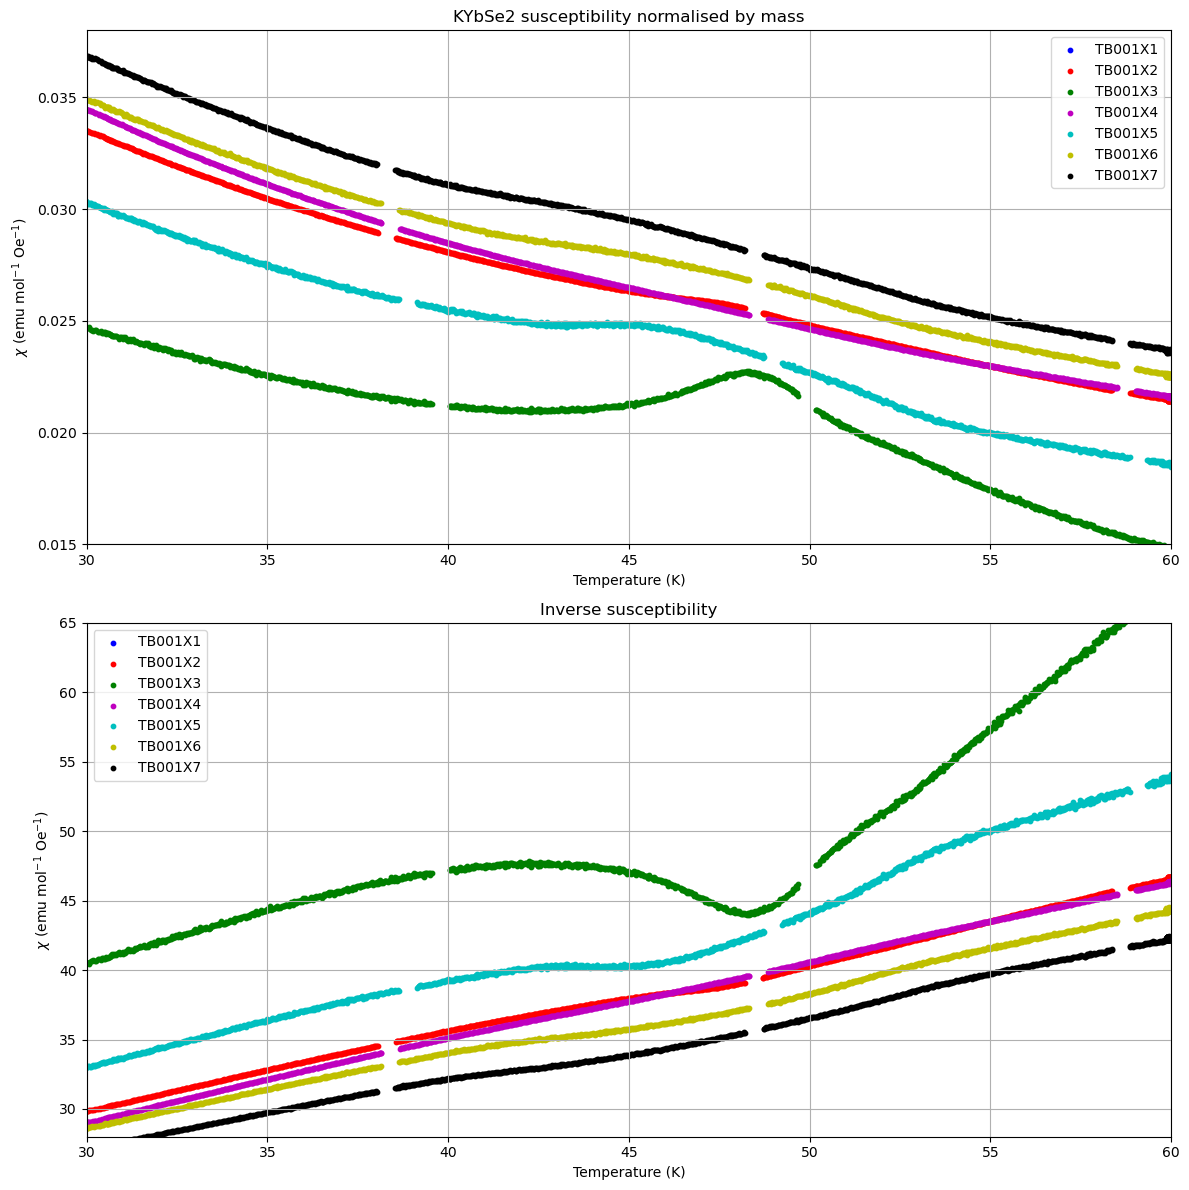

In [2]:
# -----------------------------
# Load your data
# -----------------------------
#Filepath where the point the test datafile exists in so it can be accessed
'''MAGNETISATION DATA'''
filepath = "C:/Users/TXB909/Documents/strain-cell/PPMS_Data_and_Plotting/Data/KYbSe2/Magnetisation/"
file1 = "KYBSE2_TB001X4_0P2T_HPARA_AB_290526_FCC_300TO30K.dat"
FILEANDPATHMag1=filepath+file1





#file1 = "KYBSE2_TB001X4_0P2T_HPARA_AB_290526_5KTO30K.dat"
#file2 = "KYBSE2_TB001X4_0P2T_HPARA_AB_290526_30K_TO300K.dat"

file1="KYBSE2_TB001_0P2T_HPARRA_AB_270526_FCW.dat"
file2="KYBSE2_TB001X2_0P2T_HPARA_AB_280526_FCW_30TO60K.dat"
file3="KYBSE2_TB001X3_0P2T_HPARA_AB_280526_FCW_30TO60K.dat"
file4="KYBSE2_TB001X4_0P2T_HPARA_AB_290526_001_FCW_30TO60K.dat"
file5="KYBSE2_TB001X5_0P2T_HPARA_AB_290526_10TO300K.dat"
file6="KYBSE2_TB001X6_0P2T_HPARA_AB_010626_30TO60K.dat"
file7="KYBSE2_TB001X7_0P2T_HPARA_AB_010626_30TO60K.dat"


FILE1 = filepath + file1
FILE2 = filepath + file2
FILE3 = filepath + file3
FILE4 = filepath + file4
FILE5 = filepath + file5
FILE6 = filepath + file6
FILE7 = filepath + file7

# -----------------------------
# Load datasets for stitching together 5 to 30 k and 30 to 300 K
# -----------------------------
df1, header1 = load_magnetisation_data(
    file_location=FILE1,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
df2, header2 = load_magnetisation_data(
    file_location=FILE2,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
df3, header3 = load_magnetisation_data(
    file_location=FILE3,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
df4, header4 = load_magnetisation_data(
    file_location=FILE4,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
df5, header5 = load_magnetisation_data(
    file_location=FILE5,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
df6, header6 = load_magnetisation_data(
    file_location=FILE6,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
df7, header7 = load_magnetisation_data(
    file_location=FILE7,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)

# -----------------------------
# Clean + sort (important for physics plots)
# -----------------------------
df1 = df1.replace([np.inf, -np.inf], np.nan)
df1 = df1.dropna(subset=["Temperature (K)", "Moment (emu)"])
df1 = df1.sort_values("Temperature (K)").reset_index(drop=True)

df2 = df2.replace([np.inf, -np.inf], np.nan)
df2 = df2.dropna(subset=["Temperature (K)", "Moment (emu)"])
df2 = df2.sort_values("Temperature (K)").reset_index(drop=True)

df3 = df3.replace([np.inf, -np.inf], np.nan)
df3 = df3.dropna(subset=["Temperature (K)", "Moment (emu)"])
df3 = df3.sort_values("Temperature (K)").reset_index(drop=True)

df4 = df4.replace([np.inf, -np.inf], np.nan)
df4 = df4.dropna(subset=["Temperature (K)", "Moment (emu)"])
df4 = df4.sort_values("Temperature (K)").reset_index(drop=True)

df5 = df5.replace([np.inf, -np.inf], np.nan)
df5 = df5.dropna(subset=["Temperature (K)", "Moment (emu)"])
df5 = df5.sort_values("Temperature (K)").reset_index(drop=True)

df6 = df6.replace([np.inf, -np.inf], np.nan)
df6 = df6.dropna(subset=["Temperature (K)", "Moment (emu)"])
df6 = df6.sort_values("Temperature (K)").reset_index(drop=True)

df7 = df7.replace([np.inf, -np.inf], np.nan)
df7 = df7.dropna(subset=["Temperature (K)", "Moment (emu)"])
df7 = df7.sort_values("Temperature (K)").reset_index(drop=True) 


# -----------------------------
# Extract variables
# -----------------------------
x1 = df1["Temperature (K)"]
M1 = df1["Moment (emu)"]
H1 = df1["Magnetic Field (Oe)"]
print(H1)

x2 = df2["Temperature (K)"]
M2 = df2["Moment (emu)"]
H2 = df2["Magnetic Field (Oe)"]

x3 = df3["Temperature (K)"]
M3 = df3["Moment (emu)"]
H3 = df3["Magnetic Field (Oe)"]

x4 = df4["Temperature (K)"]
M4 = df4["Moment (emu)"]
H4 = df4["Magnetic Field (Oe)"]

x5 = df5["Temperature (K)"]
M5 = df5["Moment (emu)"]
H5 = df5["Magnetic Field (Oe)"]

x6 = df6["Temperature (K)"]
M6 = df6["Moment (emu)"]
H6 = df6["Magnetic Field (Oe)"]

x7 = df7["Temperature (K)"]
M7 = df7["Moment (emu)"]
H7 = df7["Magnetic Field (Oe)"]



"""
df_mag1, header_line = load_magnetisation_data(
    file_location=FILEANDPATHMag1,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)"""

# -----------------------------
# Conversion Factor
# -----------------------------
mass1 = 0.0031  # g
mass2 = 0.0059
mass3 = 0.001
mass4 = 0.0049
mass5 = 0.001
mass6 = 0.0014
mass7 = 0.0015


molar_mass = 370.0853 # g/mol


chi1 = M1 / H1
y1 = chi1 * molar_mass / mass1
inv_y1 = 1.0 / y1

chi2 = M2 / H2
y2 = chi2 * molar_mass / mass2
inv_y2 = 1.0 / y2

chi3 = M3 / H3
y3 = chi3 * molar_mass / mass3
inv_y3 = 1.0 / y3

chi4 = M4 / H4
y4 = chi4 * molar_mass / mass4
inv_y4 = 1.0 / y4

chi5 = M5 / H5
y5 = chi5 * molar_mass / mass5
inv_y5 = 1.0 / y5

chi6 = M6 / H6
y6 = chi6 * molar_mass / mass6
inv_y6 = 1.0 / y6

chi7 = M7 / H7
y7 = chi7 * molar_mass / mass7
inv_y7 = 1.0 / y7

# -----------------------------
# Define 3-parameter Curie–Weiss
# -----------------------------
def curie_weiss_3param(T, C, theta, chi0):
    return C / (T - theta) + chi0

# -----------------------------
# Fit curie-weiss to the data
# -----------------------------
"""
mask = (x2 > 150) & (x2 < 300)   # fitting window
x_fit = x2[mask]
y_fit = y2[mask]

valid = np.isfinite(x_fit) & np.isfinite(y_fit)
x_fit = x_fit[valid]
y_fit = y_fit[valid]

popt, pcov = curve_fit(curie_weiss_3param, x_fit, y_fit,
                    p0=[0.5, 30, -0.0])  # guesses: C, theta, chi0

C_fit, theta_fit, chi0_fit = popt
perr = np.sqrt(np.diag(pcov))

# assuming C_fit and perr[0] (its 1σ) are from a fit done in emu/mol
# if you used a plotting scale_factor (e.g. 1000), DO NOT apply it here.
C_true = C_fit
dC = perr[0]

mu_eff = 2.828 * np.sqrt(C_true)                 # μB / f.u.
mu_eff_err = 2.828 * 0.5 / np.sqrt(C_true) * dC  # error propagation



print("===== Curie–Weiss Fit =====")
print(f"C      = {C_fit:.4f} ± {perr[0]:.4f} emu K mol^-1 Oe^-1")
print(f"μ_eff  = {mu_eff:.3f} ± {mu_eff_err:.3f} μB")
print(f"θ      = {theta_fit:.2f} ± {perr[1]:.2f} K")
print(f"χ₀     = {chi0_fit:.6f} ± {perr[2]:.6f} emu mol^-1 Oe^-1")

"""

# -----------------------------
# Plot χ(T) with fit
# -----------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- χ(T)

ax1.scatter(x1, y1, s=10, color='b', label="TB001X1")
ax1.scatter(x2, y2, s=10, color='r', label="TB001X2")
ax1.scatter(x3, y3, s=10, color='g', label="TB001X3")
ax1.scatter(x4, y4, s=10, color='m', label="TB001X4")
ax1.scatter(x5, y5, s=10, color='c', label="TB001X5")
ax1.scatter(x6, y6, s=10, color='y', label="TB001X6")
ax1.scatter(x7, y7, s=10, color='k', label="TB001X7")

"""
T_smooth = np.linspace(min(x_fit), max(x_fit), 500)
ax1.plot(T_smooth, curie_weiss_3param(T_smooth, *popt), 'k--',
        label=f"Curie–Weiss fit\nC={C_fit:.2f}, μ_eff = {mu_eff:.2f}, θ={theta_fit:.1f} K, χ₀={chi0_fit:.4e}")
        """

ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel(r"$\chi$ (emu mol$^{-1}$ Oe$^{-1}$)")
ax1.set_title("KYbSe2 susceptibility normalised by mass")
ax1.set_xlim(30, 60)
ax1.set_ylim(0.015, 0.038)
ax1.grid(True)
ax1.legend()

# --- χ⁻¹(T)
ax2.scatter(x1, inv_y1, s=10, color='b', label="TB001X1")
ax2.scatter(x2, inv_y2, s=10, color='r', label="TB001X2")
ax2.scatter(x3, inv_y3, s=10, color='g', label="TB001X3")
ax2.scatter(x4, inv_y4, s=10, color='m', label="TB001X4")
ax2.scatter(x5, inv_y5, s=10, color='c', label="TB001X5")
ax2.scatter(x6, inv_y6, s=10, color='y', label="TB001X6")
ax2.scatter(x7, inv_y7, s=10, color='k', label="TB001X7")

"""
# For comparison, plot inverse of fit
inv_fit = 1.0 / curie_weiss_3param(T_smooth, *popt)
ax2.plot(T_smooth, inv_fit, 'k--', linewidth=2.5)"""

ax2.set_xlabel("Temperature (K)")
ax2.set_ylabel(r"$\chi$ (emu mol$^{-1}$ Oe$^{-1}$)")
ax2.set_title("Inverse susceptibility")
ax2.set_xlim(30, 60)
ax2.set_ylim(28, 65)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()